In [17]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('default')
pd.set_option('display.max_columns', None)

In [18]:
PROJECT_ROOT = Path("/Users/brodiehasein/alberta_power_markets_project")

WEATHER_FILE = (
    PROJECT_ROOT
    / "data/features/weather/renewable_weather_features_hourly.parquet"
)

weather = pd.read_parquet(WEATHER_FILE)

weather["timestamp_utc"] = pd.to_datetime(
    weather["timestamp_utc"],
    utc=True,
)

weather = weather.sort_values("timestamp_utc").reset_index(drop=True)

In [19]:
print(weather.shape)

weather.info()

weather.head()

(100776, 51)
<class 'pandas.DataFrame'>
RangeIndex: 100776 entries, 0 to 100775
Data columns (total 51 columns):
 #   Column                                                               Non-Null Count   Dtype              
---  ------                                                               --------------   -----              
 0   timestamp_utc                                                        100776 non-null  datetime64[ns, UTC]
 1   wind_installed_capacity_mw                                           100776 non-null  float64            
 2   wind_active_project_count                                            100776 non-null  int64              
 3   wind_active_weather_site_count                                       100776 non-null  int64              
 4   wind_capacity_weighted_u_wind_100m                                   100776 non-null  float64            
 5   wind_capacity_weighted_v_wind_100m                                   100776 non-null  float64            

,timestamp_utc,wind_installed_capacity_mw,wind_active_project_count,wind_active_weather_site_count,wind_capacity_weighted_u_wind_100m,wind_capacity_weighted_v_wind_100m,wind_capacity_weighted_u_wind_10m,wind_capacity_weighted_v_wind_10m,wind_capacity_weighted_instantaneous_10m_wind_gust,wind_capacity_weighted_max_10m_wind_gust,wind_capacity_weighted_temperature_2m,wind_capacity_weighted_surface_pressure,wind_capacity_weighted_mean_sea_level_pressure,wind_capacity_weighted_temperature_850hpa,wind_capacity_weighted_u_wind_850hpa,wind_capacity_weighted_v_wind_850hpa,wind_capacity_weighted_boundary_layer_height,wind_capacity_weighted_total_cloud_cover,wind_capacity_weighted_total_precipitation,wind_capacity_weighted_snowfall,wind_capacity_weighted_snow_depth,wind_capacity_weighted_speed_100m,wind_capacity_weighted_speed_100m_squared,wind_capacity_weighted_speed_100m_cubed,wind_speed_100m_spatial_std,wind_vector_speed_100m,wind_vector_direction_100m_degrees,wind_capacity_weighted_speed_10m,wind_speed_10m_spatial_std,wind_vector_speed_10m,wind_vector_direction_10m_degrees,wind_speed_shear_100m_minus_10m,wind_speed_ratio_100m_to_10m,wind_capacity_weighted_air_density,solar_installed_capacity_mw,solar_active_project_count,solar_active_weather_site_count,solar_capacity_weighted_surface_solar_radiation_downwards,solar_capacity_weighted_surface_solar_radiation_downwards_clear_sky,solar_capacity_weighted_total_sky_direct_solar_radiation,solar_capacity_weighted_temperature_2m,solar_capacity_weighted_skin_temperature,solar_capacity_weighted_total_cloud_cover,solar_capacity_weighted_high_cloud_cover,solar_capacity_weighted_medium_cloud_cover,solar_capacity_weighted_low_cloud_cover,solar_capacity_weighted_total_precipitation,solar_capacity_weighted_snowfall,solar_capacity_weighted_snow_depth,solar_capacity_weighted_radiation_wm2,solar_clear_sky_radiation_ratio
0,2015-01-01 00:00:00+00:00,1509.22,26,15,8.545568,2.466092,4.232915,1.570201,8.092913,8.252751,268.523307,90120.299873,102324.226033,274.730695,10.573667,-1.994352,211.810203,0.736172,7.380578e-08,6.803970e-08,0.005901,8.990432,81.968744,757.232647,1.068122,8.894287,253.902847,4.545824,0.919232,4.514765,249.647651,4.444608,1.977734,1.169185,2.0,1,1,27392.0,27712.0,8896.0,269.355957,266.899353,0.926849,0.926849,0.001709,0.000000,0.0,0.0,0.013890,7.608889,0.988453
1,2015-01-01 01:00:00+00:00,1509.22,26,15,8.732688,2.297071,4.422075,1.509108,8.482130,8.464304,268.153720,90065.931114,102279.442228,275.078326,10.910929,-2.176082,208.882789,0.693665,1.107087e-07,1.176280e-07,0.005887,9.131394,84.541466,792.558591,1.076622,9.029750,255.262602,4.703536,0.902713,4.672489,251.156927,4.427858,1.941389,1.170090,2.0,1,1,0.0,0.0,0.0,269.414429,267.040497,0.767792,0.763519,0.065979,0.001709,0.0,0.0,0.013859,0.000000,NaN
2,2015-01-01 02:00:00+00:00,1509.22,26,15,8.780922,2.119415,4.439272,1.443958,8.799112,8.712415,268.070477,89984.881011,102195.655428,275.484474,10.877725,-2.673238,208.410502,0.798534,9.225723e-09,1.153215e-08,0.005874,9.231749,86.129744,811.455664,0.951085,9.033078,256.430292,4.743338,0.745809,4.668207,251.981889,4.488410,1.946256,1.169400,2.0,1,1,0.0,0.0,0.0,269.660950,267.430420,0.533417,0.523407,0.010010,0.000854,0.0,0.0,0.013827,0.000000,NaN
3,2015-01-01 03:00:00+00:00,1509.22,26,15,9.003982,1.798697,4.659966,1.279958,9.207151,9.148364,268.142119,89959.234657,102173.311132,275.802186,11.022234,-3.198635,230.313718,0.689832,2.767717e-08,2.767717e-08,0.005866,9.594445,93.277886,917.735186,1.106577,9.181885,258.702914,4.996584,0.791585,4.832554,254.641272,4.597861,1.920201,1.168754,2.0,1,1,0.0,0.0,0.0,269.889832,267.286011,0.801697,0.801697,0.008545,0.000000,0.0,0.0,0.013799,0.000000,NaN
4,2015-01-01 04:00:00+00:00,1509.22,26,15,8.910155,0.987198,4.678470,0.815046,9.430418,9.411305,268.160640,89917.795353,102122.784114,275.936685,11.000390,-3.967934,258.937183,0.747474,1.845145e-08,2.075788e-08,0.005855,9.568865,92.846249,911.935218,1.132731,8.964676,263.677715,5.022441,0.771899,4.

#### MST Timezone

In [43]:
weather["timestamp_alberta"] = (
    weather["timestamp_utc"]
    .dt.tz_convert("America/Edmonton")
)

weather["hour_alberta"] = (
    weather["timestamp_alberta"].dt.hour
)

weather["date_alberta"] = (
    weather["timestamp_alberta"].dt.date
)

weather["month_alberta"] = (
    weather["timestamp_alberta"].dt.month
)

weather["year_alberta"] = (
    weather["timestamp_alberta"].dt.year
)

#### Missing Values

In [20]:
missing = (
    weather
    .isna()
    .sum()
    .sort_values(ascending=False)
)

missing[missing > 0]

solar_clear_sky_radiation_ratio    44295
dtype: int64

In [35]:
ratio_missing = weather[
    "solar_clear_sky_radiation_ratio"
].isna()

clear_sky = weather[
    "solar_capacity_weighted_surface_solar_radiation_downwards_clear_sky"
]

actual = weather[
    "solar_capacity_weighted_surface_solar_radiation_downwards"
]

print("Missing ratio rows:", ratio_missing.sum())

print(
    "Missing ratio with zero clear-sky radiation:",
    (ratio_missing & clear_sky.eq(0)).sum(),
)

print(
    "Missing ratio with positive clear-sky radiation:",
    (ratio_missing & clear_sky.gt(0)).sum(),
)

weather.loc[
    ratio_missing,
    [
        "timestamp_utc",
        "solar_capacity_weighted_surface_solar_radiation_downwards",
        "solar_capacity_weighted_surface_solar_radiation_downwards_clear_sky",
        "solar_clear_sky_radiation_ratio",
    ],
].head(20)

Missing ratio rows: 44295
Missing ratio with zero clear-sky radiation: 44295
Missing ratio with positive clear-sky radiation: 0


,timestamp_utc,solar_capacity_weighted_surface_solar_radiation_downwards,solar_capacity_weighted_surface_solar_radiation_downwards_clear_sky,solar_clear_sky_radiation_ratio
1,2015-01-01 01:00:00+00:00,0.0,0.0,NaN
2,2015-01-01 02:00:00+00:00,0.0,0.0,NaN
3,2015-01-01 03:00:00+00:00,0.0,0.0,NaN
4,2015-01-01 04:00:00+00:00,0.0,0.0,NaN
5,2015-01-01 05:00:00+00:00,0.0,0.0,NaN
6,2015-01-01 06:00:00+00:00,0.0,0.0,NaN
7,2015-01-01 07:00:00+00:00,0.0,0.0,NaN
8,2015-01-01 08:00:00+00:00,0.0,0.0,NaN
9,2015-01-01 09:00:00+00:00,0.0,0.0,NaN
10,2015-01-01 10:00:00+00:00,0.0,0.0,NaN


#### Summary Statistics

In [21]:
weather.describe().T

,count,mean,std,min,25%,50%,75%,max
wind_installed_capacity_mw,100776.0,2826.841696,1.605107e+03,1509.220000,1509.220000,1.815820e+03,4.054920e+03,5.770420e+03
wind_active_project_count,100776.0,33.429150,8.837582e+00,26.000000,26.000000,2.800000e+01,4.200000e+01,4.900000e+01
wind_active_weather_site_count,100776.0,19.127411,5.217991e+00,15.000000,15.000000,1.600000e+01,2.500000e+01,2.800000e+01
wind_capacity_weighted_u_wind_100m,100776.0,2.408136,3.875879e+00,-9.953926,-0.506299,2.178503e+00,5.229713e+00,1.706886e+01
wind_capacity_weighted_v_wind_100m,100776.0,0.862011,3.459115e+00,-14.522084,-1.449166,1.058544e+00,3.326169e+00,1.184654e+01
wind_capacity_weighted_u_wind_10m,100776.0,1.323433,2.219536e+00,-6.704241,-0.303225,1.248651e+00,2.842868e+00,1.096904e+01
wind_capacity_weighted_v_wind_10m,100776.0,0.499478,2.063439e+00,-10.004011,-0.775743,7.241664e-01,1.954817e+00,7.605133e+00
wind_capacity_weighted_instantaneous_10m_wind_gust,100776.0,6.846058,2.920847e+00,1.360919,4.645288,6.299323e+00,8.534207e+00,2.419154e+01
wind_capacity_weighted_max_10m_wind_gust,100776.0,7.163110,2.984608e+00,1.548976,4.920660,6.607679e+00,8.894632e+00,2.518676e+01
wind_capacity_weighted_temperature_2m,100776.0,278.372890,1.184658e+01,233.567010,271.087488,2.787353e+02,2.869048e+02,3.106710e+02


#### Capacity Evolution

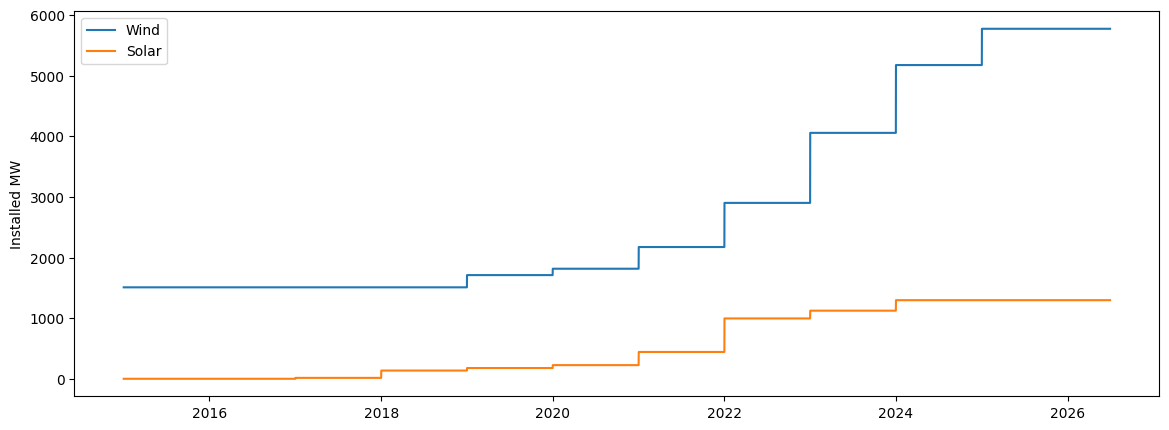

In [22]:
fig, ax = plt.subplots(figsize=(14,5))

ax.plot(
    weather["timestamp_utc"],
    weather["wind_installed_capacity_mw"],
    label="Wind",
)

ax.plot(
    weather["timestamp_utc"],
    weather["solar_installed_capacity_mw"],
    label="Solar",
)

ax.set_ylabel("Installed MW")

ax.legend()

plt.show()

#### Wind Speed

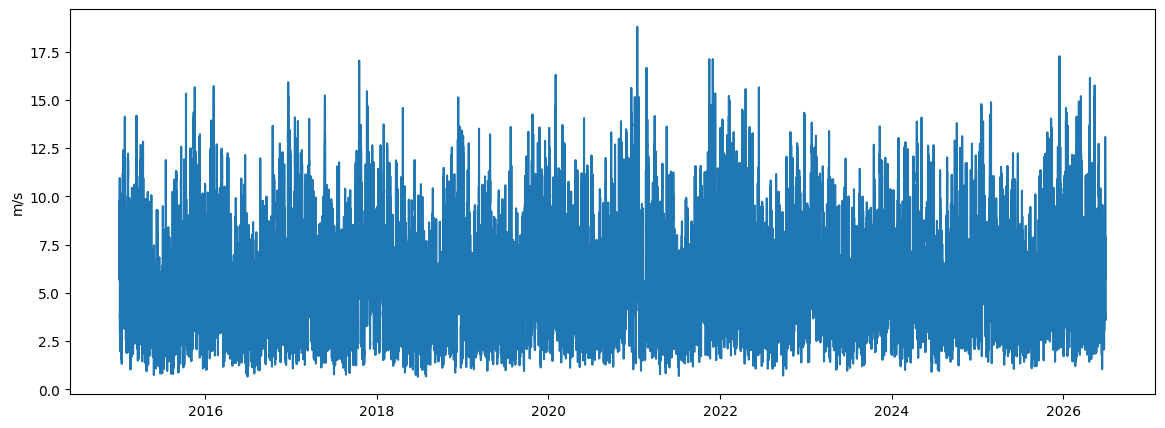

In [39]:
fig, ax = plt.subplots(figsize=(14,5))

ax.plot(
    weather["timestamp_alberta"],
    weather["wind_capacity_weighted_speed_100m"],
)

ax.set_ylabel("m/s")

plt.show()

#### Solar Radiation

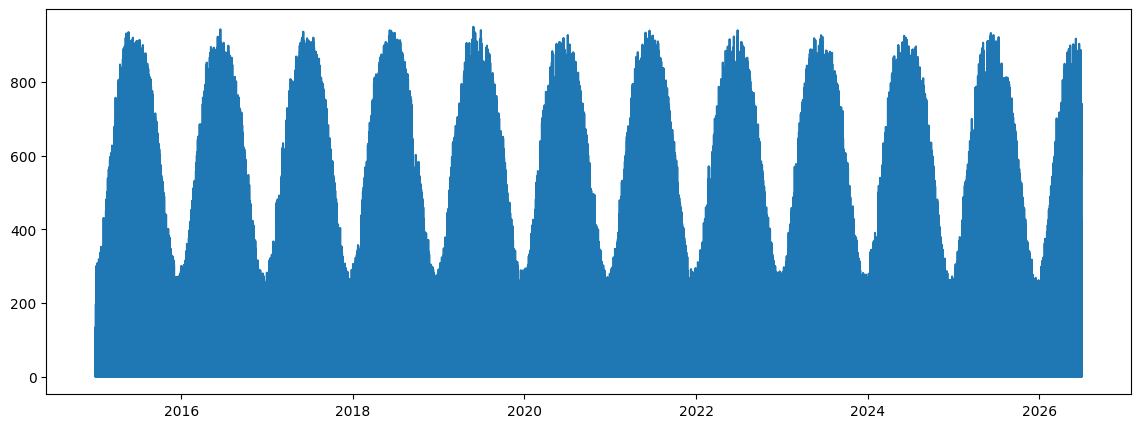

In [40]:
fig, ax = plt.subplots(figsize=(14,5))

ax.plot(
    weather["timestamp_alberta"],
    weather["solar_capacity_weighted_radiation_wm2"],
)

plt.show()

#### Histograms

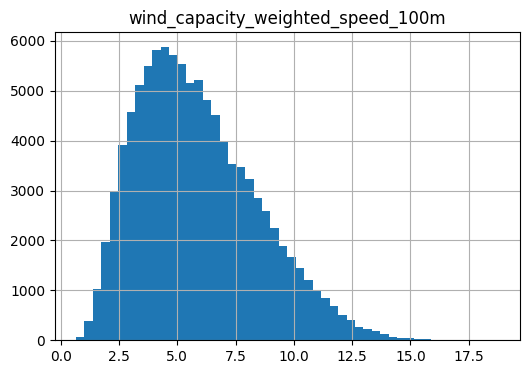

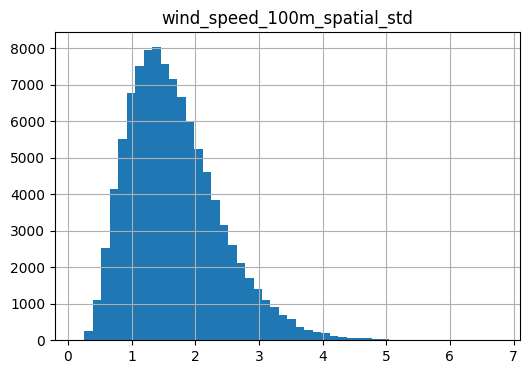

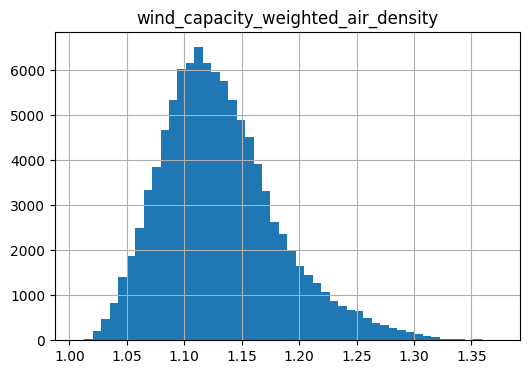

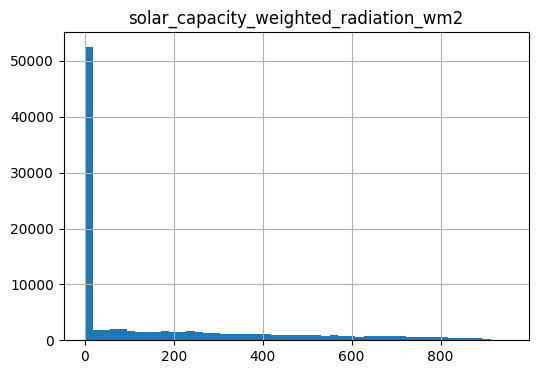

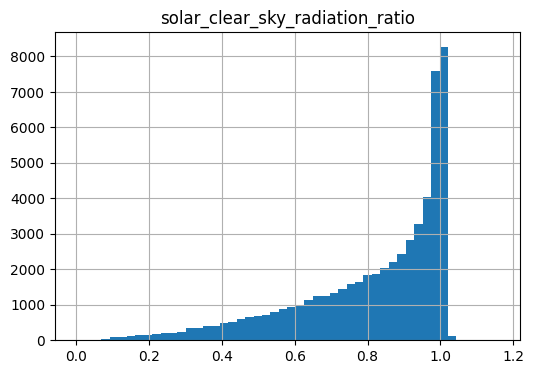

In [ ]:
important = [
    "wind_capacity_weighted_speed_100m",
    "wind_speed_100m_spatial_std",
    "wind_capacity_weighted_air_density",
    "solar_capacity_weighted_radiation_wm2",
    "solar_clear_sky_radiation_ratio",

]

for column in important:

    weather[column].hist(
        bins=50,
        figsize=(6,4),
    )

    plt.title(column)

    plt.show()

#### Daily Patterns

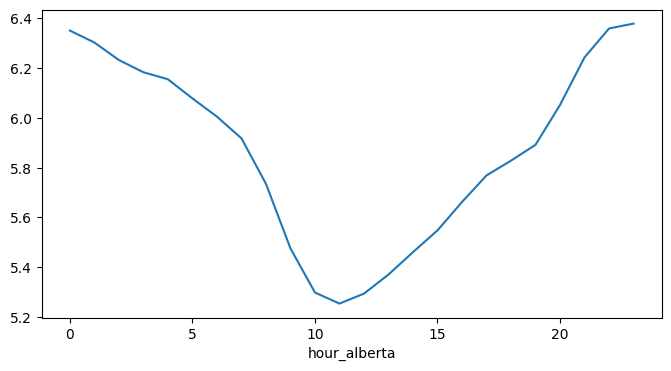

In [37]:
(
    weather
    .groupby("hour_alberta")[
        "wind_capacity_weighted_speed_100m"
    ]
    .mean()
    .plot(figsize=(8,4))
)

plt.show()

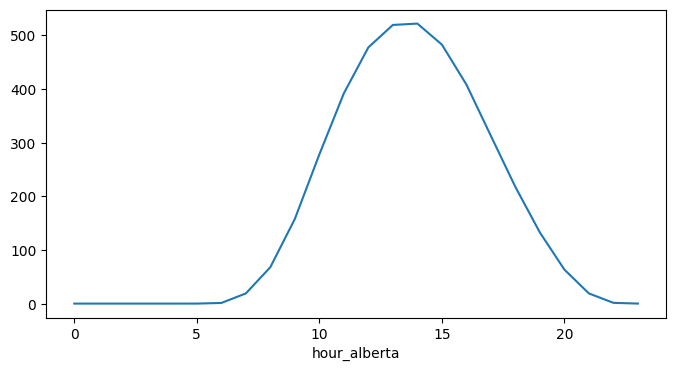

In [38]:
(
    weather
    .groupby("hour_alberta")[
        "solar_capacity_weighted_radiation_wm2"
    ]
    .mean()
    .plot(figsize=(8,4))
)

plt.show()

#### Seasonal Averages

In [44]:
(
    weather
    .groupby("month_alberta")[
        "wind_capacity_weighted_speed_100m"
    ]
    .mean()
)

month_alberta
1     6.797682
2     6.221153
3     5.921931
4     5.868090
5     5.339433
6     5.356028
7     4.633788
8     4.819696
9     5.440090
10    6.283315
11    6.987331
12    6.763574
Name: wind_capacity_weighted_speed_100m, dtype: float64

In [45]:
(
    weather
    .groupby("month_alberta")[
        "solar_capacity_weighted_radiation_wm2"
    ]
    .mean()
)

month_alberta
1      57.612701
2     101.258846
3     163.505470
4     225.559890
5     264.897192
6     285.705661
7     286.441129
8     243.218784
9     176.543098
10    112.818746
11     62.577554
12     44.329345
Name: solar_capacity_weighted_radiation_wm2, dtype: float64

#### Correlation Matrix

In [34]:
engineered = [
    "wind_capacity_weighted_speed_100m",
    "wind_capacity_weighted_speed_100m_squared",
    "wind_capacity_weighted_speed_100m_cubed",
    "wind_speed_100m_spatial_std",
    "wind_vector_speed_100m",
    "wind_speed_ratio_100m_to_10m",
    "wind_capacity_weighted_air_density",
    "solar_capacity_weighted_radiation_wm2",
    "solar_clear_sky_radiation_ratio",

]

weather[engineered].corr()

,wind_capacity_weighted_speed_100m,wind_capacity_weighted_speed_100m_squared,wind_capacity_weighted_speed_100m_cubed,wind_speed_100m_spatial_std,wind_vector_speed_100m,wind_speed_ratio_100m_to_10m,wind_capacity_weighted_air_density,solar_capacity_weighted_radiation_wm2,solar_clear_sky_radiation_ratio
wind_capacity_weighted_speed_100m,1.000000,0.969949,0.900148,0.366308,0.965004,0.315489,-0.053145,-0.218412,-0.079485
wind_capacity_weighted_speed_100m_squared,0.969949,1.000000,0.977187,0.408750,0.937832,0.229196,-0.053736,-0.189189,-0.083187
wind_capacity_weighted_speed_100m_cubed,0.900148,0.977187,1.000000,0.420134,0.871008,0.153943,-0.052086,-0.158060,-0.087964
wind_speed_100m_spatial_std,0.366308,0.408750,0.420134,1.000000,0.333204,0.065822,0.011002,-0.076113,-0.035504
wind_vector_speed_100m,0.965004,0.937832,0.871008,0.333204,1.000000,0.271174,-0.035321,-0.174051,-0.056174
wind_speed_ratio_100m_to_10m,0.315489,0.229196,0.153943,0.065822,0.271174,1.000000,0.129853,-0.720436,0.048984
wind_capacity_weighted_air_density,-0.053145,-0.053736,-0.052086,0.011002,-0.035321,0.129853,1.000000,-0.454017,-0.150135
solar_capacity_weighted_radiation_wm2,-0.218412,-0.189189,-0.158060,-0.076113,-0.174051,-0.720436,-0.454017,1.000000,0.328506
solar_clear_sky_radiation_ratio,-0.079485,-0.083187,-0.087964,-0.035504,-0.056174,0.048984,-0.150135,0.328506,1.000000
